# MFAA Chapter 10 Laboratory
**Venture Portfolio and Security Engine** (book §10.8)

Three coupled modules: financing tree, cap table (preference stacks, conversion), and portfolio/inference (power laws, skill vs luck). Seed `20261000`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch10
from dataclasses import replace

## 1. E3 — The down-round exit: security payoffs and conversion
Convertible preferred pays max{min(L,E), fE}; conversion is optimal iff E ≥ E* = L/f.

conservation error: 1.7763568394002505e-15


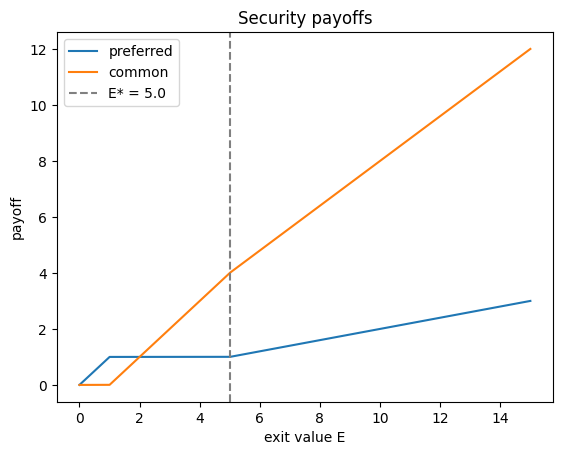

In [2]:
p = ch10.VentureParams(pref_mult=1.0, invested=1.0, ownership=0.2)
E = np.linspace(0, 15, 300)
lad = ch10.class_value_ladder(p, E)
plt.plot(E, lad['preferred'], label='preferred')
plt.plot(E, lad['common'], label='common')
plt.axvline(lad['conversion_threshold'], color='grey', ls='--', label=f"E* = {lad['conversion_threshold']:.1f}")
plt.xlabel('exit value E'); plt.ylabel('payoff'); plt.legend(); plt.title('Security payoffs')
print('conservation error:', lad['conservation_error'])

## 2. E1 — Tail index sensitivity (power laws)
The k-th Pareto moment converges iff k < α.

In [3]:
import pandas as pd
pd.DataFrame(ch10.pareto_moment_convergence(1.5, 0.3)['rows'])

,N,moment_1,moment_2
0,100,0.847732,1.861539
1,1000,0.845130,2.566828
2,10000,0.895730,16.543762
3,100000,0.862586,7.003617


## 3. E4 — Skilled or lucky?
Locate a 4.1× fund in the luck distribution; how many consecutive funds shift the odds to 9:1 for skill?

In [4]:
p = ch10.VentureParams(n=28, success_prob=0.5, alpha=1.2, x_m=0.3, prior_sd=0.25)
sl = ch10.skill_vs_luck(p, observed_multiple=4.1)
print(f"posterior P(positive drift): {sl['posterior_p_positive']:.3f}")
print(f"consecutive funds for 9:1 skill odds: {sl['consecutive_funds_for_9to1']}")

posterior P(positive drift): 0.612
consecutive funds for 9:1 skill odds: 5


## 4. Validation checks

In [5]:
v = ch10.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_conservation PASS
V2_conversion_threshold PASS
V3_pareto_moments PASS
V4_expected_max PASS
V5_participating_dominates PASS
V6_reproducible PASS
ALL: True
